# Aggregating and summarizing data

In [19]:
import pandas as pd
import plotly.express as px

pd.__version__

'2.2.2'

In [3]:
df = pd.read_csv('https://github.com/wortell-smart-learning/python-data-fundamentals/raw/main/data/most_voted_titles_enriched.csv')

df.head(3)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,genre1,...,country,primary_language,color,budget,opening_weekend_usa,gross_usa,cumulative_worldwide,tagline,summary,image_url
0,tt0010323,movie,The Cabinet of Dr. Caligari,Das Cabinet des Dr. Caligari,0,1920,NaN,76.0,"Fantasy,Horror,Mystery",Fantasy,...,Germany,NaN,Black and White,"$18,000",NaN,"$8,811","$8,811",You must become Caligari.,"Hypnotist Dr. Caligari uses a somnambulist, Ce...",https://m.media-amazon.com/images/M/MV5BNWJiNG...
1,tt0012349,movie,The Kid,The Kid,0,1921,NaN,68.0,"Comedy,Drama,Family",Comedy,...,USA,NaN,Black and White,"$250,000",NaN,NaN,"$26,916",This is the great film he has been working on ...,"The Tramp cares for an abandoned child, but ev...",https://m.media-amazon.com/images/M/MV5BZjhhMT...
2,tt0013442,movie,Nosferatu,"Nosferatu, eine Symphonie des Grauens",0,1922,NaN,94.0,"Fantasy,Horror",Fantasy,...,Germany,NaN,Black and White,NaN,NaN,NaN,"$19,054",A thrilling mystery masterpiece - a chilling p...,Vampire Count Orlok expresses interest in a ne...,https://m.media-amazon.com/images/M/MV5BMTAxYj...


### You can do a simple count of values with `.value_counts()`, but this only works on a Series (so just 1 column). Please notice the argument  `dropna=False`. Let's try it on end year.

In [20]:
df['endYear'].value_counts(dropna=False).head(5)

,count
endYear,
NaN,5395
2019.0,44
2020.0,36
2017.0,36
2018.0,34


### If you want percentages in your `.value_counts()` you can use argument `normalize=True`

In [21]:
df['endYear'].value_counts(dropna=False, normalize=True).head(5)

,proportion
endYear,
NaN,0.925386
2019.0,0.007547
2020.0,0.006175
2017.0,0.006175
2018.0,0.005832


### But one of the most powerful features of pandas is the method `.groupby()`
### This makes it possible to divide your data in groups and summarize it however you like.
### With built-in functions such as .mean(), but you also create your own custom functions

### Let's first group data by title type

In [22]:
df.groupby(by='titleType', dropna=False)

### Okay, we grouped the data, we don't see anything. We still need to specify what to do with the groups. Let's calculate a `.mean()`.

In [35]:
#Feedback geven dat hier een andere df voor gebruikt wordt.
df_new = df[['titleType','isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'averageRating', 'numVotes', 'metascore']]

df_new.groupby(by='titleType',dropna=False).mean()

,isAdult,startYear,endYear,runtimeMinutes,averageRating,numVotes,metascore
titleType,,,,,,,
movie,0.0,2001.794745,NaN,111.151561,6.754208,132880.287890,58.83015
tvSeries,0.0,2007.799308,2011.032184,44.650435,7.961938,101065.695502,NaN


### Or just a `.count()` of the columns:

In [31]:
df_new.groupby(by='titleType',dropna=False).count()

,isAdult,startYear,endYear,runtimeMinutes,averageRating,numVotes,metascore
titleType,,,,,,,
movie,5252,5252,0,5252,5252,5252,4816
tvSeries,578,578,435,575,578,578,0


### But we see a count of all the columns, I just want the `.count()` of 1 column:

In [38]:
df.groupby(by='titleType',dropna=False)[['genres']].count()

,genres
titleType,
movie,5252
tvSeries,578


### Or a count of your groups over multiple columns

In [ ]:
df.groupby(by='titleType',dropna=False)[['genres', 'startYear', 'endYear']].count()

### Or check the mean rating per start year (for movies) and use pandas plotting

<Axes: xlabel='startYear'>

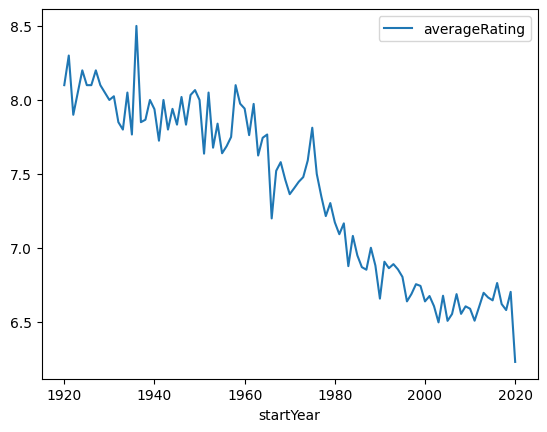

In [39]:
df.query('titleType == "movie"').groupby('startYear')[['averageRating']].mean().plot()

### But some years have much more movies than others. How does that effect the mean rating per start year. <br> Below is an example of method chaining: applying all sorts of functions after eachother.

In [40]:
df_group_startyear = (df
    .query('titleType == "movie"')
    .groupby('startYear', as_index=False)
    .agg(mean=('averageRating', 'mean'), count=('averageRating', 'count'))
)
df_group_startyear.head(3)

,startYear,mean,count
0,1920,8.1,1
1,1921,8.3,1
2,1922,7.9,1


### And let's plot the result with plotly express

In [41]:
px.scatter(
    title='Average rating per start year',
    data_frame=df_group_startyear,
    x='startYear',
    y='mean',
    size='count',
    size_max=25,
    height=400,
    width=700,
)

### There's a whole of functions you can apply to groups. These are just examples:
- count()
- mean()
- min()
- max()
- rolling()
- cumsum()
- diff()
- ffill()

See more info here:<br>https://pandas.pydata.org/pandas-docs/stable/reference/groupby.html

### Last thing: let's say you want to apply a custom aggregation to your groups. How do we do that?

In [42]:
def custom_mean_calulation(x):
    return x.mean() * 10

df.groupby('startYear')['averageRating'].apply(custom_mean_calulation)

,averageRating
startYear,
1920,81.000000
1921,83.000000
1922,79.000000
1924,82.000000
1925,81.000000
...,...
2016,69.334842
2017,68.585492
2018,67.536232


### Oh, let's say you want to group averages, but add those group averages to every row of your dataframe:

In [43]:
df['group_mean_rating'] = df.groupby('startYear')['averageRating'].transform('mean')
df[['tconst', 'startYear', 'averageRating', 'group_mean_rating']].query('startYear > 1960').head(5)

,tconst,startYear,averageRating,group_mean_rating
51,tt0035423,2001,6.4,6.781507
173,tt0054698,1961,7.6,7.762500
174,tt0054953,1961,7.5,7.762500
175,tt0054997,1961,8.0,7.762500
176,tt0055018,1961,7.8,7.762500
